# Logistic Regression 
## 1. Introduction to Logistic Regression

Logistic Regression is a **supervised machine learning algorithm** used for **classification problems**, primarily **binary classification**.

### Key Idea

* Predicts **probability** of a class (0 or 1)
* Uses a **non-linear sigmoid function**
* Converts linear combinations into probabilities

### Use Cases

* Disease prediction (Yes/No)
* Spam detection
* Customer churn
* Titanic survival



## 2. Sigmoid Function (Core of Logistic Regression)

### Mathematical Definition

σ(z) = 1 / (1 + e⁻ᶻ)

### Properties

* Output range: (0, 1)
* Smooth and differentiable
* Converts any real value into probability

### Why Sigmoid?

* Probabilities needed for classification
* Enables gradient-based optimization
* Creates non-linearity



## 3. Transition from Linear to Logistic Regression

### Linear Regression Output

ŷ = b₀ + b₁x₁ + b₂x₂ + ... + bₙxₙ

Can produce values < 0 or > 1

### Logistic Regression Output

z = b₀ + b₁x₁ + ... + bₙxₙ
P(y=1) = σ(z)

Always between 0 and 1



## 4. Mathematical Understanding

### Odds

Odds = P / (1 − P)

### Log-Odds (Logit Function)

log(P / (1 − P)) = z

This shows logistic regression is **linear in log-odds space**.



## 5. Exploratory Data Analysis (EDA)

### Goals of EDA

* Understand feature distributions
* Identify missing values
* Detect outliers
* Find feature–target relationships

### Practical Steps

* Histogram for numerical features
* Bar plots for categorical features
* Correlation matrix
* Survival rate vs feature analysis

EDA often reveals **non-linear relationships**.



## 6. Model Training (Practical Pipeline)

### Step-by-Step Workflow

1. Load dataset
2. Handle missing values
3. Encode categorical variables
4. Feature scaling
5. Train-test split
6. Train logistic regression model

### Why Scaling Matters

* Faster convergence
* Stable gradient descent



## 7. Confusion Matrix and Accuracy

### Confusion Matrix Structure

| Actual \ Predicted | Positive | Negative |
|  | -- | -- |
| Positive           | TP       | FN       |
| Negative           | FP       | TN       |

### Accuracy

Accuracy = (TP + TN) / (TP + TN + FP + FN)

Not reliable for imbalanced datasets



## 8. Classification Metric: Precision

### Formula

Precision = TP / (TP + FP)

### Interpretation

* How many predicted positives are correct?
* Important when **false positives are costly**

Example:

* Spam detection
* Fraud detection



## 9. Recall and F1 Score

### Recall

Recall = TP / (TP + FN)

Measures how many actual positives were captured.

### F1 Score

F1 = 2 × (Precision × Recall) / (Precision + Recall)

Balances precision and recall.



## 10. ROC Curve and AUC

### ROC Curve

* Plots **TPR vs FPR**
* Evaluates model at different thresholds

### AUC (Area Under Curve)

* Range: 0.5 to 1
* Higher AUC = better classifier

### Interpretation

* AUC = 0.5 → random model
* AUC = 1 → perfect model



## 11. Performance Evaluation Strategy

### Metrics Selection

* Balanced data → Accuracy
* Imbalanced data → Precision, Recall, AUC

### Validation Techniques

* Cross-validation
* Stratified sampling



## 12. Multiclass Classification

Logistic Regression can handle multiple classes using:

### One-vs-Rest (OvR)

* Train one classifier per class

### Softmax (Multinomial Logistic Regression)

P(y=k) = eᶻᵏ / Σeᶻ

Used when classes are mutually exclusive.



## 13. Capstone Project (End-to-End)

### Problem Statement

Predict whether a Titanic passenger survives.

### Steps

1. Data understanding
2. EDA & visualization
3. Feature engineering
4. Model training
5. Threshold tuning
6. Evaluation using ROC-AUC
7. Interpretation & reporting

### Deliverables

* Clean notebook
* Evaluation report
* Business insights



## 14. Common Practical Issues

* Multicollinearity
* Class imbalance
* Overfitting

### Solutions

* Regularization (L1, L2)
* Class weights
* Feature selection




## 16. Final Summary

* Logistic regression is a **foundational ML algorithm**
* Strong balance of math + interpretability
* Essential for real-world classification problems
* Forms the base for neural networks



## 1. Problem Statement

**Goal:** Predict whether a Titanic passenger survived or not.

* Target Variable: `Survived` (0 = No, 1 = Yes)
* Model Used: **Logistic Regression**
* Evaluation Focus: **ROC–AUC**



## 2. Data Understanding

### Dataset Overview

Typical Titanic dataset columns:

* PassengerId
* Survived (Target)
* Pclass
* Sex
* Age
* SibSp
* Parch
* Fare
* Embarked

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("C:\\Users\\LENOVO\\Desktop\\NetTech\\Machine Learning\\titanic.csv")
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [2]:
drop_cols = [col for col in df.columns if 'zero' in col.lower()]

df.drop(columns=drop_cols, inplace=True, errors='ignore')

In [3]:
df.rename(columns={'2urvived': 'Survived'}, inplace=True)

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   Parch        1309 non-null   int64  
 6   Pclass       1309 non-null   int64  
 7   Embarked     1307 non-null   float64
 8   Survived     1309 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 92.2 KB


,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1307.000000,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,0.385027,2.294882,1.492731,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.865560,0.837836,0.814626,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,0.000000,3.000000,2.000000,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,0.000000,3.000000,2.000000,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,9.000000,3.000000,2.000000,1.000000


In [5]:
df

,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0
...,...,...,...,...,...,...,...,...,...
1304,1305,28.0,8.0500,0,0,0,3,2.0,0
1305,1306,39.0,108.9000,1,0,0,1,0.0,0
1306,1307,38.5,7.2500,0,0,0,3,2.0,0
1307,1308,28.0,8.0500,0,0,0,3,2.0,0


## 3. EDA & Visualization

In [6]:
# Survival Distribution

df['Survived'].value_counts()

Survived
0    967
1    342
Name: count, dtype: int64

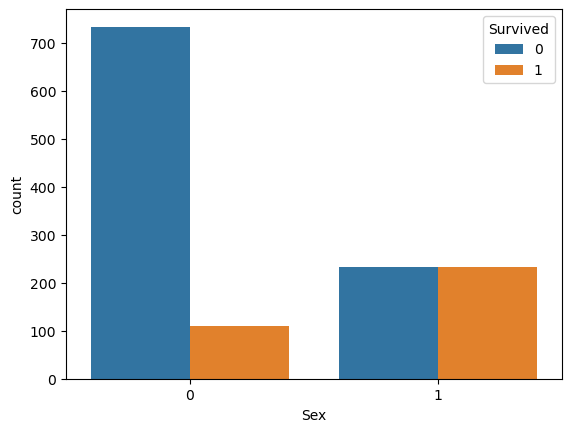

In [7]:
# Survival by Gender

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Sex', hue='Survived', data=df)
plt.show()

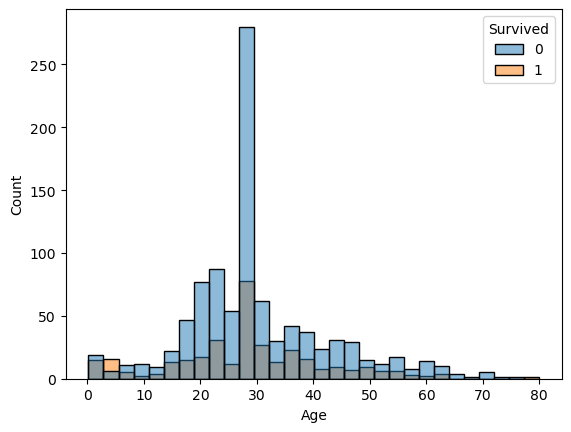

In [8]:
### Age vs Survival

sns.histplot(data=df, x='Age', hue='Survived', bins=30)
plt.show()

### Key Insights from EDA

* Females survived more than males
* Children had higher survival chances
* Higher fare & class → higher survival

## 4. Feature Engineering

In [9]:
### Handling Missing Values

df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_30668\2777731210.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_30668\2777731210.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [10]:
### Encoding Categorical Variables

df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

In [11]:
### Feature Selection

X = df.drop(['Survived', 'Passengerid'], axis=1)
y = df['Survived']

## 5. Train-Test Split & Scaling

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Model Training (Logistic Regression)

In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## 7. Threshold Tuning

In [14]:
### Default Prediction (0.5 Threshold)


y_pred_default = model.predict(X_test_scaled)

In [15]:
### Probability Predictions

y_probs = model.predict_proba(X_test_scaled)[:,1]

In [16]:
### Custom Threshold (e.g. 0.4)

custom_threshold = 0.4
y_pred_custom = (y_probs >= custom_threshold).astype(int)

## 8. Evaluation using ROC–AUC

In [17]:
### Confusion Matrix

from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_custom)

array([[163,  31],
       [ 38,  30]])

In [18]:
### Classification Report


from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.81      0.84      0.83       194
           1       0.49      0.44      0.47        68

    accuracy                           0.74       262
   macro avg       0.65      0.64      0.65       262
weighted avg       0.73      0.74      0.73       262



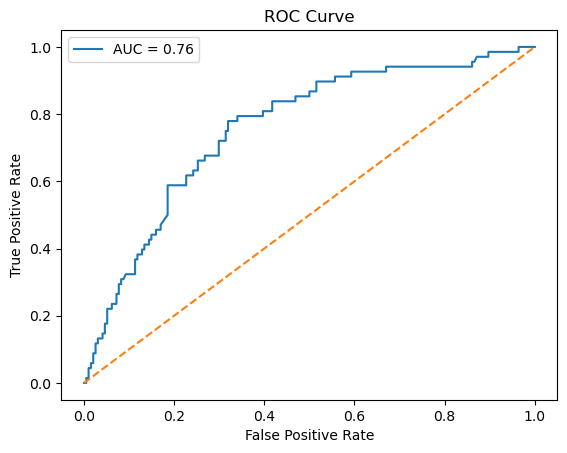

In [19]:
### ROC Curve & AUC

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [20]:
## 9. Model Interpretation

In [21]:
### Feature Importance (Coefficients)


importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

importance

,Feature,Coefficient
5,Sex_1,0.928582
6,Embarked_1.0,0.002185
3,Parch,-0.011146
7,Embarked_2.0,-0.034337
1,Fare,-0.060680
2,sibsp,-0.162976
0,Age,-0.421208
4,Pclass,-0.738791


### Interpretation Examples

* Being **female** increases survival probability
* Higher **fare** → higher survival
* Higher **Pclass number** → lower survival



## 10. Reporting & Business Insights

### Key Findings

* Gender is the strongest predictor
* Socio-economic status strongly affects survival
* Logistic regression gives interpretable probabilities

### Business / Decision Insights

* Priority-based evacuation improves survival
* Logistic regression supports transparent decisions
* Threshold tuning adapts model to business cost

## 11. Final Conclusion
 
* Logistic regression is simple yet powerful
* Titanic dataset shows strong non-linear patterns
* Threshold tuning & ROC-AUC are critical
* Excellent baseline model for classification problems